# GLIMT Crowd Alignment Report

In [54]:
from list_all_ifps import list_all_ifps
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None)

In [ ]:
L = list_all_ifps()
ifps = [ifp for ifp in L if ifp['state'] == 'active']
id_to_ifp = {ifp['id']: ifp for ifp in ifps}
len(ifps)

In [59]:
alignment = [(ifp['id'], ifp['props']['title'], np.linalg.norm(np.array(ifp['myFcst']['probas'])-np.array(ifp['crowdFcst']['probas']))) for ifp in ifps]
df = pd.DataFrame(alignment, columns = ['id', 'title', 'distance']).sort_values(by='distance')
df

,id,title,distance
18,502,"Will there be protests of political nature in Belarus during 2025, according to Carnegie Endowments Global Protest Tracker?",0.004607
16,499,"Will Ramzan Kadyrov remain as Head of the Chechen Republic until December 1, 2025?",0.006628
4,470,"Will Russia use a nuclear weapon in Ukraine before December 31, 2025?",0.096409
13,492,"In 2025, will Donald Trump win the Nobel Peace Prize?",0.166938
14,493,"At the end of 2025, will Elon Musk still be the richest multi-billionaire (Forbes)?",0.180205
17,501,"What will the economic growth be in the G20 countries during the second quarter (Q2) 2025, compared with the quarter before, based on real GDP?",0.188729
5,471,Will Russian gas supplies resume through the Nord Stream pipelines in 2025?,0.211993
3,469,By what date will Russia regain control of the Kursk region?,0.218594
6,472,Will mass protests against the war with Ukraine take place in Russia in 2025?,0.235765
8,475,"What will be the volume of the liquid part of the National Wealth Fund of Russia as of October 1, 2025",0.268657


In [77]:
mean = np.mean(distances)
std = np.std(distances)

In [78]:
mean,std

(0.30855111476216573, 0.21246574627466763)

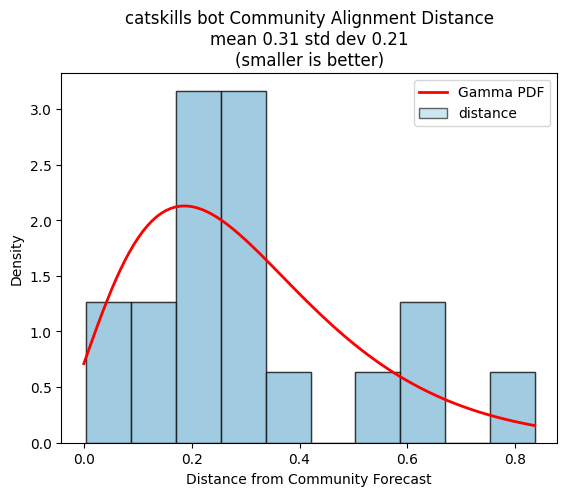

In [83]:
import matplotlib.pyplot as plt
from scipy.stats import gamma
distances = df['distance'].values

params = gamma.fit(distances)
x = np.linspace(0, distances.max(), 100)
pdf = gamma.pdf(x, *params)
plt.hist(distances, bins=10, density=True, alpha=0.5, edgecolor='black')
plt.plot(x, pdf, 'r-', lw=2, label='Gamma PDF')
df['distance'].plot.hist(bins=10, density=True, alpha=0.6, edgecolor='black', color='lightblue')
plt.xlabel('Distance from Community Forecast')
plt.ylabel('Density')
plt.title(f'catskills bot Community Alignment Distance\nmean {mean:0.2f} std dev {std:0.2f}\n(smaller is better)')
plt.legend()
plt.show()